# 🎵 Spotify Hit Predictor — Phase 3: Modelling

**Goal:** Train and compare 3 machine learning models to predict whether a song will chart on the Billboard Hot 100.

### What we'll build:
1. **Data preparation** — train/test split, scaling, class balance
2. **Logistic Regression** — simple baseline model
3. **Random Forest** — stronger ensemble model
4. **XGBoost** — best performing model
5. **Model comparison** — accuracy, ROC-AUC, precision, recall
6. **Feature importance** — what actually makes a hit?
7. **Save the model** — ready for Phase 5 dashboard

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import pickle

# Machine learning
from sklearn.model_selection     import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing       import StandardScaler
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier
from sklearn.metrics             import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils               import resample
import xgboost as xgb

warnings.filterwarnings('ignore')

# ── Styling ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#fafafa',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

HIT_COLOR  = '#1DB954'
FLOP_COLOR = '#535353'
ACCENT     = '#FF6B35'

OUTPUTS  = '../outputs/figures'
MODELS   = '../outputs/models'
os.makedirs(OUTPUTS, exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

print('✅  Setup complete')

✅  Setup complete


## 1. Load & Prepare Data

In [2]:
# ── Load master dataset from Phase 2 ─────────────────────────────────────
df = pd.read_csv('../data/master_dataset.csv')
print(f'✅  Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(3)

✅  Loaded 41,106 rows × 21 columns


,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,is_hit,decade,duration_min
0,Lucky Man,Montgomery Gentry,spotify:track:4GiXBCUF7H6YfNQsnBRIzl,0.578,0.471,4,-7.270,1,0.0289,0.368000,...,0.159,0.532,133.061,196707,4,30.88059,13,1,2000,3.278450
1,On The Hotline,Pretty Ricky,spotify:track:1zyqZONW985Cs4osz9wlsu,0.704,0.854,10,-5.477,0,0.1830,0.018500,...,0.148,0.688,92.988,242587,4,41.51106,10,1,2000,4.043117
2,Clouds Of Dementia,Candlemass,spotify:track:6cHZf7RbxXCKwEkgAZT4mY,0.162,0.836,9,-3.009,1,0.0473,0.000111,...,0.174,0.300,86.964,338893,4,65.32887,13,0,2000,5.648217


In [3]:
# ── Define features and target ────────────────────────────────────────────
#
# We use the 11 audio features from Spotify.
# We EXCLUDE: track, artist, uri (identifiers not useful for prediction)
# We INCLUDE: decade as a feature (music trends change over time)

FEATURES = [
    'danceability',
    'energy',
    'valence',
    'tempo',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'duration_ms',
    'chorus_hit',
    'sections',
    'key',
    'mode',
    'time_signature',
    'decade',
]

TARGET = 'is_hit'

# Drop rows with any missing values in our feature set
df_clean = df[FEATURES + [TARGET]].dropna()
print(f'Rows after dropping nulls: {len(df_clean):,}')
print(f'Features: {len(FEATURES)}')
print(f'\nClass balance:')
print(df_clean[TARGET].value_counts())
print(f'Hit rate: {df_clean[TARGET].mean()*100:.1f}%')

Rows after dropping nulls: 41,106
Features: 16

Class balance:
is_hit
1    20553
0    20553
Name: count, dtype: int64
Hit rate: 50.0%


In [4]:
# ── Handle class imbalance ────────────────────────────────────────────────
#
# If hits and flops are unequal, models get lazy and just predict
# the majority class. We fix this by downsampling the majority class
# so both classes have equal representation.

hits  = df_clean[df_clean[TARGET] == 1]
flops = df_clean[df_clean[TARGET] == 0]

print(f'Before balancing — Hits: {len(hits):,}  |  Flops: {len(flops):,}')

# Downsample whichever class is larger
min_size = min(len(hits), len(flops))

hits_balanced  = resample(hits,  n_samples=min_size, random_state=42)
flops_balanced = resample(flops, n_samples=min_size, random_state=42)

df_balanced = pd.concat([hits_balanced, flops_balanced]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f'After balancing  — Hits: {min_size:,}  |  Flops: {min_size:,}')
print(f'Total dataset size: {len(df_balanced):,}')

Before balancing — Hits: 20,553  |  Flops: 20,553
After balancing  — Hits: 20,553  |  Flops: 20,553
Total dataset size: 41,106


In [5]:
# ── Train / Test split ────────────────────────────────────────────────────
#
# 80% training, 20% testing
# stratify=y ensures the hit/flop ratio is equal in both splits

X = df_balanced[FEATURES]
y = df_balanced[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set:  {len(X_train):,} songs')
print(f'Test set:      {len(X_test):,}  songs')

# ── Scale features for Logistic Regression ───────────────────────────────
# Tree-based models (RF, XGBoost) don't need scaling
# but Logistic Regression performs much better with it
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\n✅  Data ready for modelling')

Training set:  32,884 songs
Test set:      8,222  songs

✅  Data ready for modelling


## 2. Model 1 — Logistic Regression (Baseline)

Simple, fast, and highly interpretable. This is our baseline to beat.

In [6]:
print('Training Logistic Regression...')

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

# Predictions
y_pred_lr  = lr.predict(X_test_s)
y_prob_lr  = lr.predict_proba(X_test_s)[:, 1]

# Scores
acc_lr  = accuracy_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

# Cross-validation for more reliable estimate
cv_lr = cross_val_score(lr, X_train_s, y_train,
                         cv=StratifiedKFold(5), scoring='roc_auc').mean()

print(f'\n  Accuracy:       {acc_lr*100:.1f}%')
print(f'  ROC-AUC:        {auc_lr:.3f}')
print(f'  CV ROC-AUC:     {cv_lr:.3f}')
print(f'\n{classification_report(y_test, y_pred_lr, target_names=["Flop","Hit"])}')

Training Logistic Regression...

  Accuracy:       74.0%
  ROC-AUC:        0.809
  CV ROC-AUC:     0.806

              precision    recall  f1-score   support

        Flop       0.79      0.66      0.72      4111
         Hit       0.71      0.82      0.76      4111

    accuracy                           0.74      8222
   macro avg       0.75      0.74      0.74      8222
weighted avg       0.75      0.74      0.74      8222



## 3. Model 2 — Random Forest

In [7]:
print('Training Random Forest... (may take ~30 seconds)')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1       # use all CPU cores
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Scores
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
cv_rf  = cross_val_score(rf, X_train, y_train,
                          cv=StratifiedKFold(5), scoring='roc_auc').mean()

print(f'\n  Accuracy:       {acc_rf*100:.1f}%')
print(f'  ROC-AUC:        {auc_rf:.3f}')
print(f'  CV ROC-AUC:     {cv_rf:.3f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Flop","Hit"])}')

Training Random Forest... (may take ~30 seconds)

  Accuracy:       83.2%
  ROC-AUC:        0.907
  CV ROC-AUC:     0.901

              precision    recall  f1-score   support

        Flop       0.90      0.74      0.82      4111
         Hit       0.78      0.92      0.85      4111

    accuracy                           0.83      8222
   macro avg       0.84      0.83      0.83      8222
weighted avg       0.84      0.83      0.83      8222



## 4. Model 3 — XGBoost (Best Model)

In [8]:
print('Training XGBoost... (may take ~1 minute)')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Scores
acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
cv_xgb  = cross_val_score(xgb_model, X_train, y_train,
                            cv=StratifiedKFold(5), scoring='roc_auc').mean()

print(f'\n  Accuracy:       {acc_xgb*100:.1f}%')
print(f'  ROC-AUC:        {auc_xgb:.3f}')
print(f'  CV ROC-AUC:     {cv_xgb:.3f}')
print(f'\n{classification_report(y_test, y_pred_xgb, target_names=["Flop","Hit"])}')

Training XGBoost... (may take ~1 minute)

  Accuracy:       86.7%
  ROC-AUC:        0.939
  CV ROC-AUC:     0.931

              precision    recall  f1-score   support

        Flop       0.91      0.82      0.86      4111
         Hit       0.83      0.92      0.87      4111

    accuracy                           0.87      8222
   macro avg       0.87      0.87      0.87      8222
weighted avg       0.87      0.87      0.87      8222



## 5. Model Comparison

In [9]:
# ── Summary table ─────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr,  acc_rf,  acc_xgb],
    'ROC-AUC':  [auc_lr,  auc_rf,  auc_xgb],
    'CV AUC':   [cv_lr,   cv_rf,   cv_xgb],
})
results[['Accuracy','ROC-AUC','CV AUC']] = results[
    ['Accuracy','ROC-AUC','CV AUC']
].apply(lambda x: x.round(3))

print('=== MODEL COMPARISON ===')
print(results.to_string(index=False))
best = results.loc[results['ROC-AUC'].idxmax(), 'Model']
print(f'\n🏆  Best model: {best}')

=== MODEL COMPARISON ===
              Model  Accuracy  ROC-AUC  CV AUC
Logistic Regression     0.740    0.809   0.806
      Random Forest     0.832    0.907   0.901
            XGBoost     0.867    0.939   0.931

🏆  Best model: XGBoost


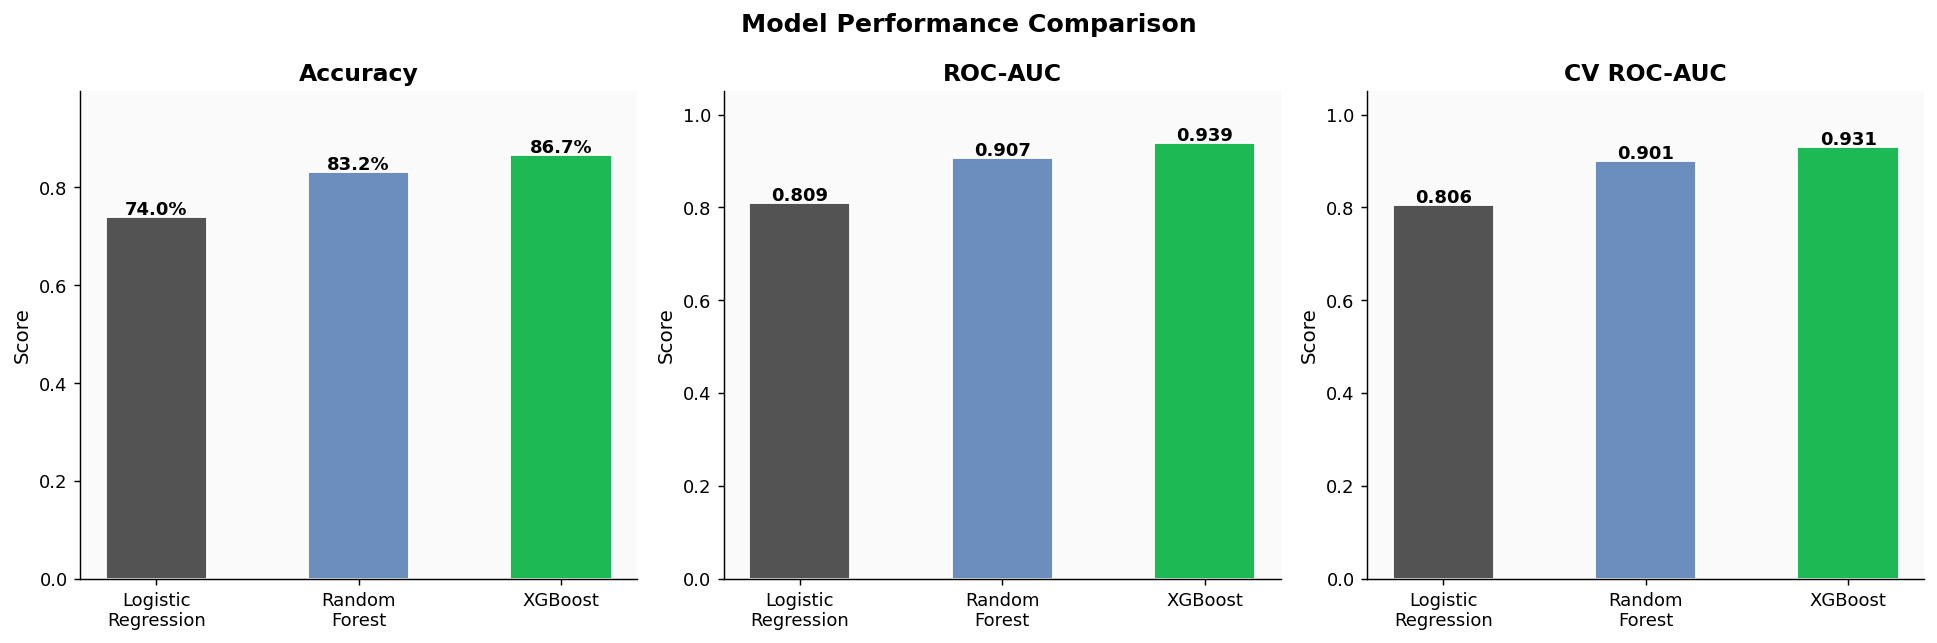

In [10]:
# ── Visual comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models      = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
accuracies  = [acc_lr,  acc_rf,  acc_xgb]
aucs        = [auc_lr,  auc_rf,  auc_xgb]
cv_aucs     = [cv_lr,   cv_rf,   cv_xgb]
bar_colors  = [FLOP_COLOR, '#6c8ebf', HIT_COLOR]

for ax, values, title, fmt in [
    (axes[0], accuracies, 'Accuracy',    '{:.1%}'),
    (axes[1], aucs,       'ROC-AUC',     '{:.3f}'),
    (axes[2], cv_aucs,    'CV ROC-AUC',  '{:.3f}'),
]:
    bars = ax.bar(models, values, color=bar_colors,
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                fmt.format(val),
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, min(max(values) * 1.15, 1.05))
    ax.set_ylabel('Score')

plt.suptitle('Model Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/12_model_comparison.png', bbox_inches='tight')
plt.show()

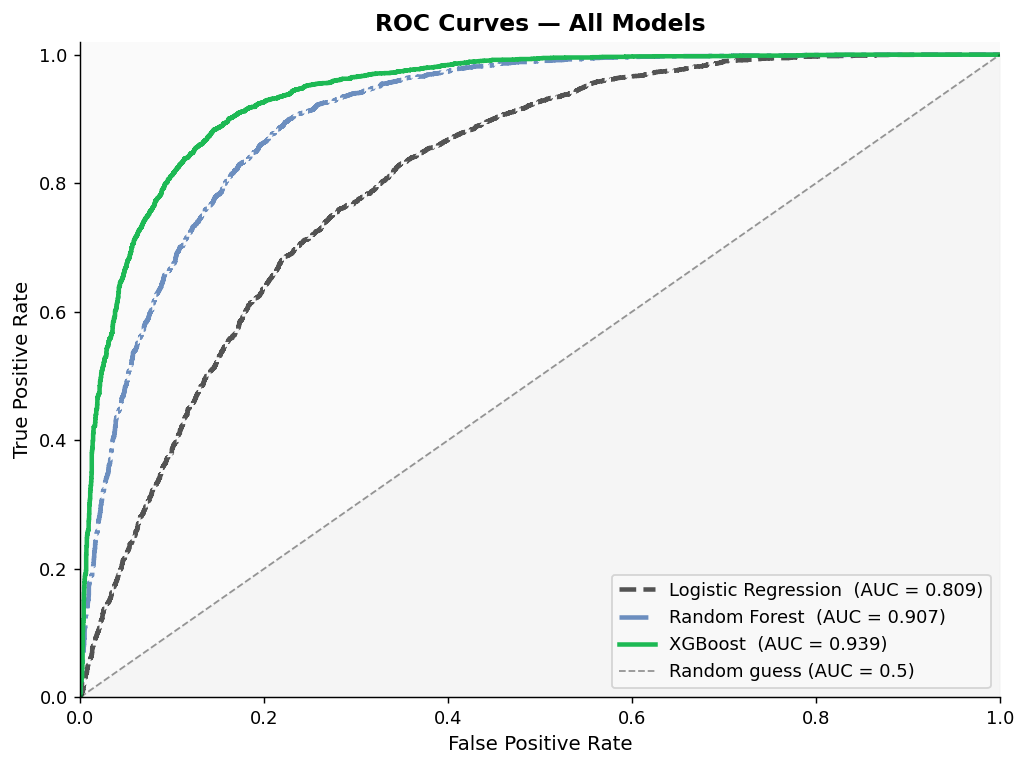

In [11]:
# ── ROC Curves for all 3 models ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color, ls in [
    ('Logistic Regression', y_prob_lr,  FLOP_COLOR, '--'),
    ('Random Forest',       y_prob_rf,  '#6c8ebf',  '-.'),
    ('XGBoost',             y_prob_xgb, HIT_COLOR,  '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val     = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5, color=color, linestyle=ls,
            label=f'{name}  (AUC = {auc_val:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.4, label='Random guess (AUC = 0.5)')
ax.fill_between([0,1], [0,1], alpha=0.04, color='gray')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/13_roc_curves.png', bbox_inches='tight')
plt.show()

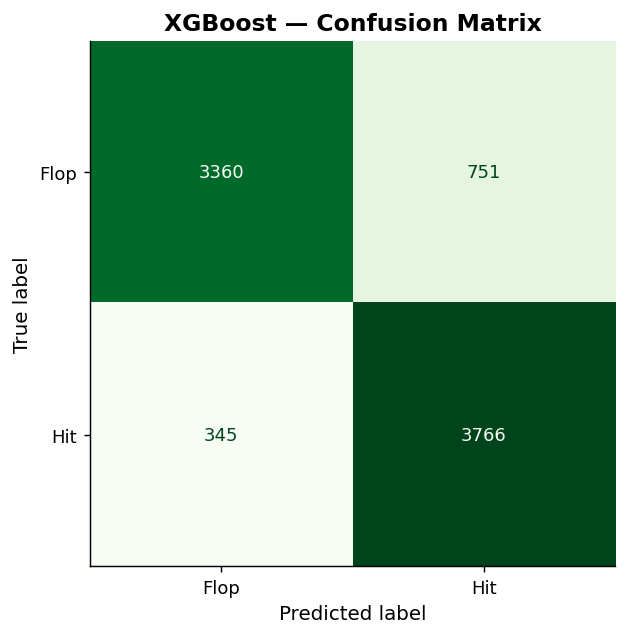


True Positives  (hits correctly predicted):   3,766
True Negatives  (flops correctly predicted):  3,360
False Positives (flops predicted as hits):    751
False Negatives (hits predicted as flops):    345


In [12]:
# ── Confusion matrix for best model (XGBoost) ────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Flop', 'Hit']
)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('XGBoost — Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/14_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Positives  (hits correctly predicted):   {tp:,}')
print(f'True Negatives  (flops correctly predicted):  {tn:,}')
print(f'False Positives (flops predicted as hits):    {fp:,}')
print(f'False Negatives (hits predicted as flops):    {fn:,}')

## 6. Feature Importance — What Makes a Hit?

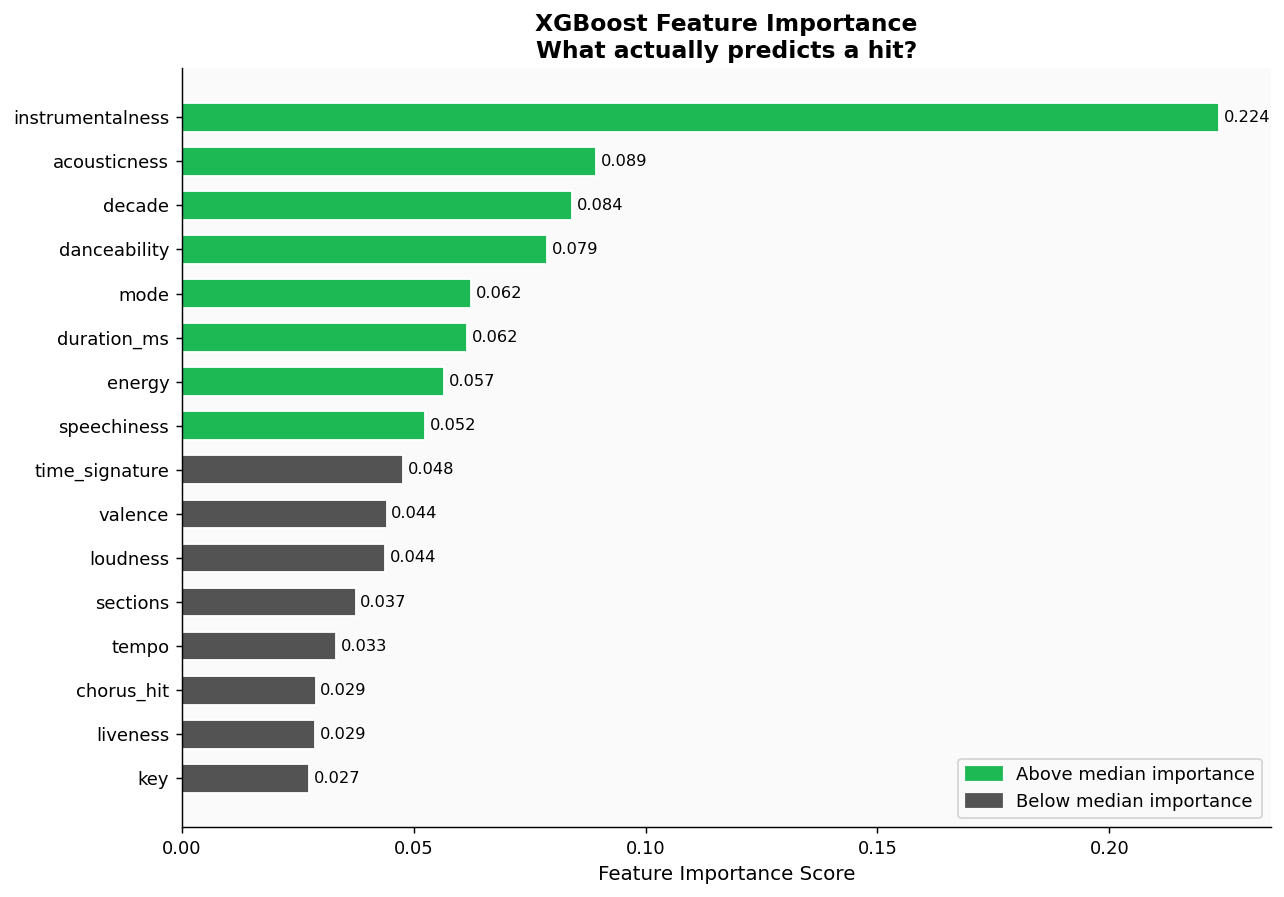


Top 5 most important features:
         feature  importance
instrumentalness    0.223723
    acousticness    0.089280
          decade    0.084093
    danceability    0.078731
            mode    0.062301


In [13]:
# ── XGBoost feature importance ────────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [HIT_COLOR if v > importance_df['importance'].median()
          else FLOP_COLOR for v in importance_df['importance']]

bars = ax.barh(importance_df['feature'],
               importance_df['importance'],
               color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score')
ax.set_title('XGBoost Feature Importance\nWhat actually predicts a hit?',
             fontsize=13, fontweight='bold')

high_patch = mpatches.Patch(color=HIT_COLOR,  label='Above median importance')
low_patch  = mpatches.Patch(color=FLOP_COLOR, label='Below median importance')
ax.legend(handles=[high_patch, low_patch], loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/15_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(importance_df.tail(5)[['feature','importance']]
      .sort_values('importance', ascending=False)
      .to_string(index=False))

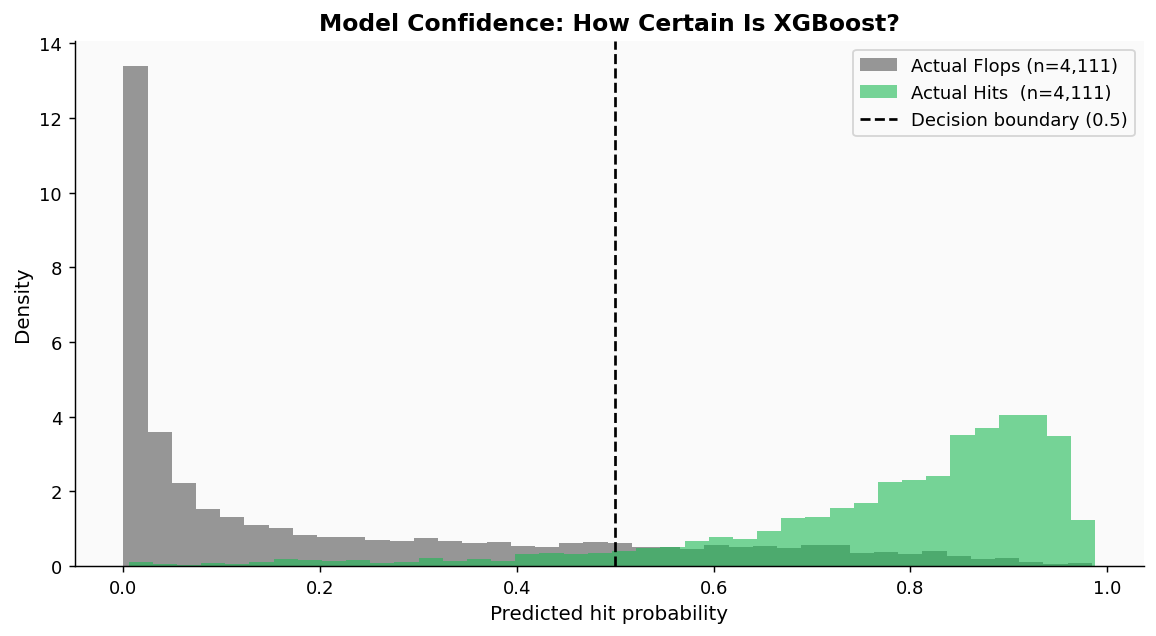

In [14]:
# ── Hit probability distribution ─────────────────────────────────────────
# How confident is the model when it predicts hits vs flops?

fig, ax = plt.subplots(figsize=(9, 5))

hit_probs  = y_prob_xgb[y_test == 1]
flop_probs = y_prob_xgb[y_test == 0]

ax.hist(flop_probs, bins=40, color=FLOP_COLOR, alpha=0.6,
        label=f'Actual Flops (n={len(flop_probs):,})', density=True)
ax.hist(hit_probs,  bins=40, color=HIT_COLOR,  alpha=0.6,
        label=f'Actual Hits  (n={len(hit_probs):,})',  density=True)

ax.axvline(0.5, color='black', lw=1.5, linestyle='--', label='Decision boundary (0.5)')
ax.set_xlabel('Predicted hit probability')
ax.set_ylabel('Density')
ax.set_title('Model Confidence: How Certain Is XGBoost?',
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/16_probability_distribution.png', bbox_inches='tight')
plt.show()

## 7. Save the Model

In [15]:
# ── Save XGBoost model + scaler + feature list ────────────────────────────
# These 3 files are everything Phase 5 (dashboard) needs

model_bundle = {
    'model':    xgb_model,
    'scaler':   scaler,
    'features': FEATURES,
    'metadata': {
        'accuracy': round(acc_xgb, 4),
        'roc_auc':  round(auc_xgb, 4),
        'cv_auc':   round(cv_xgb,  4),
        'trained_on': len(X_train),
    }
}

model_path = f'{MODELS}/xgboost_hit_predictor.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'✅  Model saved → {model_path}')
print(f'\n   Model performance summary:')
print(f'   Accuracy:  {acc_xgb*100:.1f}%')
print(f'   ROC-AUC:   {auc_xgb:.3f}')
print(f'   CV AUC:    {cv_xgb:.3f}')
print(f'\n   Saved bundle contains:')
print(f'   - xgb_model  (trained XGBoost classifier)')
print(f'   - scaler     (StandardScaler fitted on training data)')
print(f'   - features   (list of {len(FEATURES)} feature names in correct order)')
print(f'   - metadata   (model performance stats)')

✅  Model saved → ../outputs/models/xgboost_hit_predictor.pkl

   Model performance summary:
   Accuracy:  86.7%
   ROC-AUC:   0.939
   CV AUC:    0.931

   Saved bundle contains:
   - xgb_model  (trained XGBoost classifier)
   - scaler     (StandardScaler fitted on training data)
   - features   (list of 16 feature names in correct order)
   - metadata   (model performance stats)


## 8. Try It — Predict a Song Manually

In [16]:
# ── Manually predict a song ───────────────────────────────────────────────
# Edit these values to try any song!
# You can look up any song's features at:
# https://developer.spotify.com/console/get-audio-features-track/
#
# OR just estimate based on what you know about the song:
#   danceability:     Is it easy to dance to?     (0=no, 1=yes)
#   energy:           How intense/loud is it?     (0=calm, 1=intense)
#   valence:          How happy does it sound?    (0=sad, 1=happy)
#   acousticness:     Is it acoustic?             (0=electronic, 1=acoustic)

test_song = {
    'name':             'Blinding Lights',   # just for display
    'danceability':     0.514,
    'energy':           0.730,
    'valence':          0.334,
    'tempo':            171.0,
    'loudness':         -5.934,
    'speechiness':      0.060,
    'acousticness':     0.001,
    'instrumentalness': 0.0,
    'liveness':         0.096,
    'duration_ms':      200040,
    'chorus_hit':       20.0,
    'sections':         9,
    'key':              1,
    'mode':             1,
    'time_signature':   4,
    'decade':           2010,
}

# Build input dataframe in the correct feature order
input_df = pd.DataFrame([{f: test_song[f] for f in FEATURES}])

# Predict
hit_prob   = xgb_model.predict_proba(input_df)[0][1]
prediction = 'HIT 🎉' if hit_prob >= 0.5 else 'FLOP 😬'

print(f'Song: {test_song["name"]}')
print(f'─' * 35)
print(f'Hit probability:  {hit_prob*100:.1f}%')
print(f'Prediction:       {prediction}')

# Visual probability bar
bar_filled = int(hit_prob * 30)
bar = '█' * bar_filled + '░' * (30 - bar_filled)
print(f'\n[{bar}] {hit_prob*100:.0f}%')

Song: Blinding Lights
───────────────────────────────────
Hit probability:  89.4%
Prediction:       HIT 🎉

[██████████████████████████░░░░] 89%


## 9. Phase 3 Summary

In [17]:
print('=' * 60)
print('  PHASE 3 SUMMARY — Spotify Hit Predictor')
print('=' * 60)
print(f'''
📊 MODELS TRAINED:
   Logistic Regression  →  Accuracy: {acc_lr*100:.1f}%  AUC: {auc_lr:.3f}
   Random Forest        →  Accuracy: {acc_rf*100:.1f}%  AUC: {auc_rf:.3f}
   XGBoost              →  Accuracy: {acc_xgb*100:.1f}%  AUC: {auc_xgb:.3f}  ⬅ best

🏆 BEST MODEL: XGBoost
   Saved → outputs/models/xgboost_hit_predictor.pkl

🎯 TOP PREDICTIVE FEATURES:''')

top5 = importance_df.tail(5).sort_values('importance', ascending=False)
for _, row in top5.iterrows():
    print(f'   {row["feature"]:<22} {row["importance"]:.4f}')

print(f'''
📁 CHARTS SAVED → outputs/figures/
   12_model_comparison.png
   13_roc_curves.png
   14_confusion_matrix.png
   15_feature_importance.png
   16_probability_distribution.png

✅  READY FOR PHASE 5:
   Open 05_dashboard.py to build the interactive
   Streamlit app where users can score any song!
''')

  PHASE 3 SUMMARY — Spotify Hit Predictor

📊 MODELS TRAINED:
   Logistic Regression  →  Accuracy: 74.0%  AUC: 0.809
   Random Forest        →  Accuracy: 83.2%  AUC: 0.907
   XGBoost              →  Accuracy: 86.7%  AUC: 0.939  ⬅ best

🏆 BEST MODEL: XGBoost
   Saved → outputs/models/xgboost_hit_predictor.pkl

🎯 TOP PREDICTIVE FEATURES:
   instrumentalness       0.2237
   acousticness           0.0893
   decade                 0.0841
   danceability           0.0787
   mode                   0.0623

📁 CHARTS SAVED → outputs/figures/
   12_model_comparison.png
   13_roc_curves.png
   14_confusion_matrix.png
   15_feature_importance.png
   16_probability_distribution.png

✅  READY FOR PHASE 5:
   Open 05_dashboard.py to build the interactive
   Streamlit app where users can score any song!

